<h1 style="color: #CEDDF4;">DEPI Round 4, MS Data Engineer and AI Track</h1>
<h2 style="color: #CEDDF4;" >Final Project: Gold and Oil Prediction System</h2>
<h3 style="color: #CEDDF4;" > Part (2): Python Code for Machine Learning and Modeling</h3>

<h4 style="color: #CEDDF4;" >1. Import Libraries</h4>

In [331]:
import pandas as pd
import numpy as np
import math
import re
from pathlib import Path
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import joblib
from sklearn.preprocessing import StandardScaler
from functools import reduce
color_pal = sns.color_palette()
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error



In [332]:
base_dir = Path.cwd()
#raw data path to contain all raw files gathered either manually, web scraping or APIs
raw_data_dir=base_dir/'raw data'
#cleaned data path, will be separated into two main folders which are: market data (contains the data with daily logs) and macroeconomic data
##cleaned market data
cleaned_market_data_dir=base_dir/'cleaned data'/'market_data'
##cleaned macroeconomic data
cleaned_macro_data_dir=base_dir/'cleaned data'/'macroeconomic_data'
##ai modeling data
ai_data_dir=base_dir/'ai model'

<h4 style="color: #CEDDF4;" >1. Data Loading and Processing</h4>

In [333]:
def make_tag(filename):
    return re.sub(r'global_|_prices|_price|_index|_rate', '', filename)

In [334]:
#the below function is made to call all the date within specific folder (market / macro) and make final cleaning and sorting methods on it to be using in our master table
def loading(filename, tag, dir):
    df = pd.read_csv(dir / f"{filename}.csv")
    df = df.drop(columns=['id', 'region', 'ticker'], errors='ignore')
    df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='mixed', errors='coerce')
    df = df.rename(columns={c: f"{tag}_{c}" for c in df.columns if c != 'date'})
    df = df.drop_duplicates(subset='date')
    df = df.set_index('date')
    full_dates = pd.date_range(start='2016-01-01', end='2026-03-29', freq='D')
    df = df.reindex(full_dates).bfill()
    df = df.reset_index().rename(columns={'index': 'date'})
    return df

In [335]:
#the below is for loop to iterate over all files within cleaned market data 
all_market_df=[]
for filepath in cleaned_market_data_dir.glob("*.csv"):
    raw_file_name = filepath.stem
    tag = make_tag(raw_file_name)
    new_df = loading(raw_file_name, tag, cleaned_market_data_dir)
    all_market_df.append(new_df)

In [336]:
#the below is for loop to iterate over all files within cleaned macroeconomic data data 
all_macro_df=[]
for filepath in cleaned_macro_data_dir.glob("*.csv"):
    raw_file_name = filepath.stem
    tag = make_tag(raw_file_name)
    new_df = loading(raw_file_name, tag, cleaned_macro_data_dir)
    all_macro_df.append(new_df)

In [337]:

###get all dataframes from previous steps in one dataframe as reduce function takes only one argument
all_df = all_macro_df + all_market_df
#create the master table and make data column the primary key for merging process
master_table = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), all_df)
master_table = master_table.dropna(axis=1, how='all')

In [338]:
#saving the master table into a csv file to be used in the modeling
master_table.to_csv(ai_data_dir/'master_table.csv')

In [339]:
df = pd.read_csv(ai_data_dir/'master_table.csv')

In [340]:

### Checking for null values
df.isnull().sum() 

Unnamed: 0                   0
date                         0
china_cpi_value              0
china_energy_oil_elec_pct    0
china_energy_energy_use      0
                            ..
usa_nasdaq_open_usd          0
usa_sp500_price_usd          0
usa_sp500_high_usd           0
usa_sp500_low_usd            0
usa_sp500_open_usd           0
Length: 185, dtype: int64

In [341]:

### Filling null values
df = df.ffill()

In [342]:
prcentage_coulms = [
    'egy_cbe_inflations_headline_inflation_yy',
    'egy_cbe_inflations_core_inflation_yy'
]
price_columns = [
'egy_gold_price_oz_egp',
'egy_gold_open_price_egp',
'egy_gold_high_price_egp',
'egy_gold_low_price_egp'
]
for col in prcentage_coulms:
    df[col] = df[col].str.replace("%", "").astype(float) / 100

for col in price_columns:
    df[col] = df[col].str.replace(",", "").astype(float)

In [343]:

### crate a new master table without null values
df.to_csv(ai_data_dir/'master_table 2 .csv')

In [344]:
df = pd.read_csv(ai_data_dir/'master_table 2 .csv')
df.dtypes

Unnamed: 0.1                   int64
Unnamed: 0                     int64
date                          object
china_cpi_value              float64
china_energy_oil_elec_pct    float64
                              ...   
usa_nasdaq_open_usd          float64
usa_sp500_price_usd          float64
usa_sp500_high_usd           float64
usa_sp500_low_usd            float64
usa_sp500_open_usd           float64
Length: 186, dtype: object

In [345]:
df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0', 'gpr_event'], inplace=True)

<Axes: title={'center': 'Gold Price USD'}, xlabel='date'>

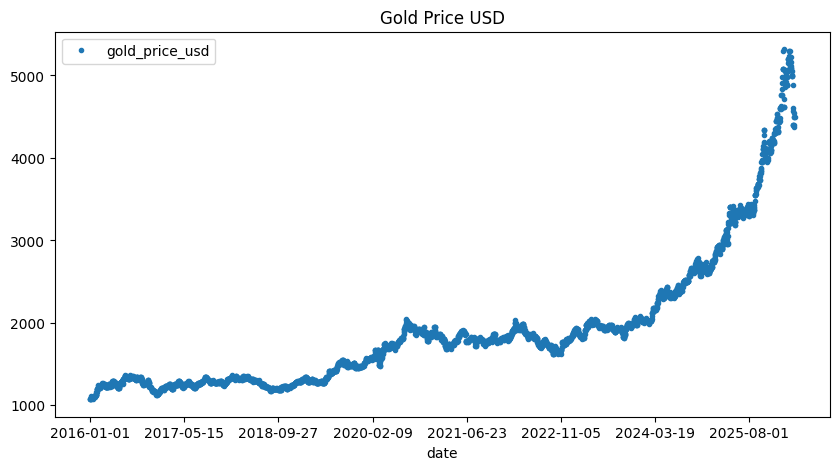

In [346]:

### Plotting the gold price over time
df.plot(
    x= 'date',
    y='gold_price_usd',
    style='.' ,
    figsize=(10,5),
    color = color_pal[0],
    title='Gold Price USD'
    )

In [348]:

target_col = "gold_price_usd"

drop_cols = [
    'gold_high_usd','gold_low_usd','gold_open_usd',
    'egy_gold_price_oz_egp','egy_gold_open_price_egp',
    'egy_gold_high_price_egp','egy_gold_low_price_egp'
]

drop_cols += [col for col in df.columns if 'energy_' in col]
drop_cols += [col for col in df.columns if any(x in col for x in ['high','low','open'])]
drop_cols += ['ai_gpr_Unnamed: 0']

df.drop(columns=drop_cols, inplace=True, errors='ignore')


In [349]:

### Features and target realsionship
currency_features = [
    'usa_dollarindex_value',
    'eurusd_price_usd',
    'gbpusd_price_usd',
    'jpyusd_price_usd',
    'cnyusd_price_usd',
    'egy_egpusd_value'
]

rates_features = [
    'usd_fedfunds_value',
    'usa_10yy_value',
    'usa_2yy_value',
    'usa_5yy_value',
    'usa_30yy_value'
]

inflation_features = [
    'usa_cpi_value',
    'euro_inflation_value',
    'egy_cpi_value'
]

risk_features = [
    'vix_price_usd',
    'gpr_gpr',
    'ai_gpr_gpr_ai',
    'ai_gpr_gpr_oil'
]

commodity_features = [
    'silver_price_usd',
    'copper_price_usd',
    'brent_oil_price_usd',
    'wti_price_usd',
    'opec_basket_value'
]

equity_features = [
    'usa_sp500_price_usd',
    'usa_nasdaq_price_usd',
    'usa_dowjones_price_usd'
]


macro_features = [
    'china_cpi_value',
    'china_gdp_value_usd',
    'japan_cpi_value',
    'euro_gdp_value'
]
price_features = [
    'silver_price_usd','copper_price_usd',
    'brent_oil_price_usd','wti_price_usd',
    'usa_sp500_price_usd','usa_nasdaq_price_usd',
    'usa_dowjones_price_usd',
    'eurusd_price_usd','gbpusd_price_usd','jpyusd_price_usd'
]



selected_features = (
    currency_features +
    rates_features +
    inflation_features +
    risk_features +
    commodity_features +
    equity_features +
    macro_features
)



In [350]:

### Date handling + sorting (IMPORTANT BEFORE FEATURES)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by="date")

In [351]:
for col in price_features:
    if col in df.columns:
        df[col + "_ret"] = df[col].pct_change()


for col in selected_features:
    if col in df.columns:
        df[col + "_lag1"] = df[col].shift(1)
        df[col + "_lag7"] = df[col].shift(7)

for col in selected_features:
    if col in df.columns:
        df[col + "_ma7"] = df[col].rolling(7).mean()


df["gold_lag1"] = df[target_col].shift(1)
df["gold_lag7"] = df[target_col].shift(7)
df["gold_ma7"] = df[target_col].rolling(7).mean()
df["gold_ret"] = df[target_col].pct_change()

df = df.dropna()

C:\Users\Basio_Wolf\AppData\Local\Temp\ipykernel_25812\1962757562.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col + "_ma7"] = df[col].rolling(7).mean()
C:\Users\Basio_Wolf\AppData\Local\Temp\ipykernel_25812\1962757562.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col + "_ma7"] = df[col].rolling(7).mean()
C:\Users\Basio_Wolf\AppData\Local\Temp\ipykernel_25812\1962757562.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor 

In [352]:

### Align target AFTER transformations
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]


X_train = train.drop(columns=[target_col, "date"])
y_train = train[target_col]

X_test = test.drop(columns=[target_col, "date"])
y_test = test[target_col]


In [353]:
model = XGBRegressor(
    n_estimators=700,      
    learning_rate=0.03,    
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [354]:
y_pred = model.predict(X_test)

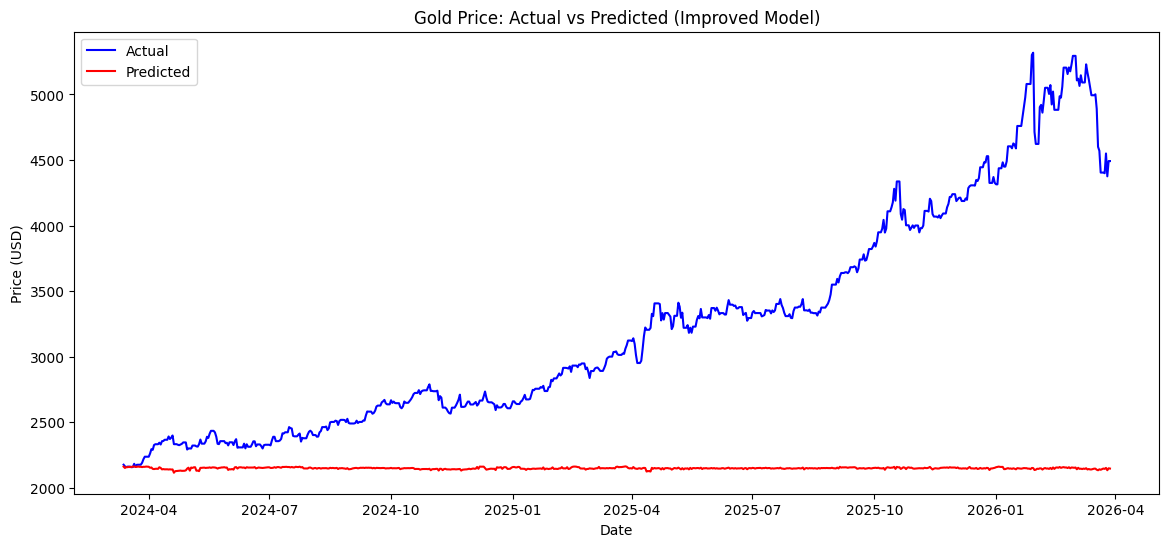

MAE: 1079.4514075067025
RMSE: 1364.0430982055013


In [355]:
import matplotlib.pyplot as plt

results = test.copy()
results["predicted"] = y_pred

plt.figure(figsize=(14,6))

plt.plot(results["date"], results[target_col],
         label="Actual", color="blue")

plt.plot(results["date"], results["predicted"],
         label="Predicted", color="red")

plt.title("Gold Price: Actual vs Predicted (Improved Model)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

In [356]:
import pandas as pd
pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)

gold_ma7                    0.435817
gold_lag1                   0.411271
gold_lag7                   0.087115
norway_cpi_value            0.024058
china_gdp_value_usd_lag1    0.009750
china_gdp_value_usd_ma7     0.007369
china_cpi_value_lag1        0.003801
usa_cpi_value_lag1          0.002295
usd_fedfunds_value_lag7     0.001772
egy_cpi_value_lag1          0.001757
dtype: float32